# 🚂💨 The Numerical Train is Getting Heated Up
### Team Mirzakhani — MAT 433, Spring 2026
**Arav · Aziza · E · Essey · Monica · Ruben**'


In this collab, we vibe-coded the Task 2 for finding the first order model for T(t) which we label as T_1(t), and task 4 for the integration of E using the first ODE model T_1(t) with 3 methods: spline, lagrange, and trapezoidal rule.
---

---
## Setup — Loading the Datasets

Before anything else, we load our three datasets. Each one contains **299 outside
temperature readings**, one every 10 seconds, so the journey runs from $t = 0$ to
$t = 2980$ seconds — just under 50 minutes.

- **Dataset 1:** Outside temperature stays relatively stable around 77°F — the mild day scenario.
- **Dataset 2:** Outside temperature gradually drops from about 64°F to 59°F.
- **Dataset 3:** Outside temperature drops dramatically from 81°F all the way down to about 54°F — the worst-case scenario. Essentially typical bipolar Kentucky weather.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
data_set_1 = np.array([
76.7852502,76.69796426,76.89134301,76.30171388,76.67313049,77.2792743,
77.53145764,77.66169781,77.9926826,78.0913486,78.14532511,78.00874062,
77.36779737,78.08816233,77.93878974,78.08690743,77.95352444,78.02765675,
77.60721279,77.33202624,77.04036036,77.05590361,77.06411722,77.47110621,
77.164872,77.09908059,76.72899239,77.35948915,77.72825364,77.90082659,
77.59180081,77.84617639,78.19909732,77.7064007,77.26654819,76.91971601,
76.76891218,76.75635994,76.43328374,76.43532345,76.15986049,76.17451314,
75.9875181,75.97830996,76.3011261,76.47628034,76.43071032,76.41512897,
76.41663335,76.52664764,76.62683295,76.81945034,76.3149894,76.48953932,
77.01356744,77.27013198,77.64683739,77.22954489,77.49627888,77.78010571,
77.89187183,77.94872367,77.78497705,77.04561814,77.40227607,77.60567689,
77.24619214,77.65854012,77.74238971,78.0090177,77.74390859,78.20568826,
77.75412167,77.11030614,77.00753981,76.86766773,76.43147648,76.18112571,
76.28770962,76.81043144,77.41357565,77.70528129,77.42533892,77.20847282,
77.77980515,77.58412212,77.1650689,76.99762984,76.75201381,77.07164156,
77.01960122,76.98082117,76.97079512,76.63847022,76.86719414,76.95876615,
76.66741808,77.08610592,77.05866971,76.70661436,76.69096216,76.89550027,
76.97777634,76.72611121,76.74064421,77.05244154,76.78968624,76.45122046,
76.97407917,77.02380883,76.96271408,77.20356236,77.55540596,77.54237009,
77.36638267,77.48417752,78.11022866,77.91424174,78.05535961,78.59366608,
77.98745721,78.18516982,78.43696435,77.88101638,77.72044886,78.290681,
78.35567951,78.43610637,78.46339917,78.7622243,78.77397998,78.76496141,
78.98607543,79.38457684,79.63421032,79.43159522,79.605724,79.51620345,
79.23166996,79.17825974,78.81732567,79.03571704,78.55881274,78.67865425,
78.69876231,79.57916132,79.35835611,78.9065429,79.3886718,79.21032321,
79.26860998,79.12029135,79.15690003,79.39325647,79.40605962,79.16511981,
79.3044807,78.9610579,78.3209837,77.76311983,78.00105277,78.11644156,
78.36231166,78.42667504,77.69214535,77.8243556,78.04917872,77.89495868,
77.67640149,77.57398796,77.60293096,77.5062117,78.36743385,77.89996455,
77.71318038,77.7698647,77.96744233,78.08158734,77.86756564,77.73367993,
77.41488768,77.29246075,77.43079529,77.16868403,77.07636423,77.24571303,
77.45898972,77.11712097,76.9733587,76.85747226,77.47447461,77.67101737,
77.587731,77.72814058,78.07432926,78.09951324,77.54821105,77.57371037,
77.40328213,77.36253125,77.08262472,77.2189559,76.96366675,77.22085646,
77.31582883,76.9186568,76.91559574,77.08371782,77.23417868,77.2898665,
77.42435537,77.40448851,77.28668283,77.32682641,77.26350719,77.35219117,
77.64523383,77.4116557,77.33751877,77.15577035,77.29963518,77.16327925,
76.38621777,76.28119345,76.93844342,76.55156584,76.54726257,76.48350113,
76.56990063,76.29580481,76.60615892,76.73019636,76.68147245,77.26247878,
77.70796596,77.45724526,77.18710015,77.45396348,76.93948613,77.05246913,
77.16754585,77.22092533,77.08287324,76.99691926,77.4165714,77.83699068,
77.24469025,77.03190732,76.77707525,76.53799026,76.28749912,77.12879001,
77.13575066,77.21950091,76.83330453,77.37727551,76.73331277,77.42218095,
77.62874523,77.38893045,77.28546629,77.62199339,77.680832,77.8640313,
78.06645162,77.83620416,77.64283356,77.23171549,77.42547618,77.24162779,
77.06336643,76.77937725,76.6997063,77.00114315,76.90092543,77.31381453,
76.89608451,76.8403066,76.79248075,76.43881222,76.4885426,76.47798427,
76.33987691,75.8311396,75.91776317,75.85551306,75.64873806,75.84669672,
75.32041725,75.57893149,75.13279683,75.30683637,75.34038038,75.79360716,
75.47914289,75.07023101,75.49427597,76.02994159,76.46762155
])

In [10]:
data_set_2 = np.array([
63.8820352,63.96056511,63.77699469,63.87814212,63.90924844,63.79331277,
63.72554295,63.62625988,63.57415936,63.65206969,64.04091213,64.00579064,
63.80811046,63.93668178,63.88222033,64.06021108,64.17498064,64.1338608,
64.06538481,63.67433172,63.56115103,63.82939806,63.54850633,63.52908522,
63.40717263,63.77193524,63.92657381,64.00298729,63.82569051,64.3005871,
64.31982367,64.08173853,63.65754312,63.85563678,64.0197858,64.17140248,
64.1424454,64.11211406,63.87907233,63.81185738,63.60444376,64.14953829,
64.60944,64.82870195,64.98638673,64.91725019,65.09847122,65.15085264,
64.89394414,64.91374199,64.74724372,64.46712803,64.5577311,64.27762446,
64.12797287,64.27502735,64.2020399,64.13821206,64.251753,64.20351719,
64.06126097,63.80162128,64.07675239,64.00387108,64.07199779,63.84667672,
63.85059446,63.49103168,63.15605208,63.14130543,62.88146987,62.58970451,
62.75504082,62.5549181,62.68113681,62.70520735,62.51742359,62.51604234,
62.3944283,62.27463358,62.10060296,62.16036869,61.82485258,61.64351369,
61.47504581,61.58654826,61.54092261,61.74004167,61.29498278,61.39814847,
60.87082122,60.93675603,60.57713092,60.40251859,60.37963308,60.32103635,
60.35314836,60.48909277,60.14666798,60.36388427,60.12858769,59.93662285,
59.48436717,59.17226551,59.02633124,59.19558825,59.68526207,59.56123298,
59.89368093,59.65382543,59.55650091,59.5489586,59.43352408,59.46248966,
59.55733467,59.68405348,59.97525099,59.97210091,59.77426401,59.69198217,
59.71444365,59.75279285,59.74258734,59.81487959,59.71495048,59.97766278,
60.32804016,60.48543216,60.37287828,60.27708344,60.33907336,60.1955474,
60.11169087,59.84747436,60.11248278,60.29262504,60.33001277,60.37443247,
60.05892278,60.51796162,60.20796938,60.17903909,60.28853719,60.42953211,
60.46519452,60.47030814,60.39521853,60.09375423,60.25215342,60.1316429,
59.9784828,59.77862969,60.15784213,60.10058089,60.14695919,60.26618705,
60.00936689,60.22327776,59.77860534,59.29870378,59.19087784,58.99120064,
59.02377144,59.04498996,58.99441665,59.07705123,59.01651196,59.1174091,
59.23290278,59.06689893,59.20429354,59.56042919,59.58588144,59.29484148,
59.03018676,59.03635911,58.62415534,58.51369711,58.65949164,58.68350726,
59.13506616,58.69476257,58.45807886,58.68751365,58.82914476,58.97705407,
58.42693354,58.51651222,58.68530971,58.95808475,59.00457889,59.00170773,
58.6468117,58.71067468,59.06787895,59.33089429,59.06640824,59.12861738,
59.18553088,59.42344604,59.53558072,59.49395729,59.73929549,59.81419122,
59.80540977,59.81168031,59.90467749,60.02219126,60.49530827,60.23150368,
60.15693341,59.89467112,60.02150982,60.33450808,60.40724652,60.1500957,
60.34722537,60.53974365,60.4318941,60.53661642,60.28060047,60.63965865,
60.41300095,60.63338543,60.77355018,60.85046128,61.01194124,61.16680949,
61.26543232,61.11199858,61.09716987,61.28936935,60.83330933,60.97738661,
61.16478385,61.40840165,61.62144722,61.71810725,61.49002626,61.65580507,
61.49971191,61.52804535,61.22794758,61.12712657,61.20416806,61.10868505,
61.12956303,60.94052707,60.95789068,60.7206382,60.85977463,60.55493081,
60.83059574,60.73608466,60.72577202,60.87401349,61.23376703,61.14158727,
61.52095132,62.19349804,62.26273219,62.40955016,61.86913901,61.68201749,
61.564881,61.47244785,61.38706783,61.31627308,61.30964846,61.46683637,
61.59474393,61.28098588,61.07113309,61.41274257,61.38919431,61.15687061,
60.9302642,60.63319677,60.8750154,60.85494348,60.79369134,60.70532476,
60.60594538,60.6572485,60.49935303,61.0740547,61.29828345,60.91452593,
61.50388987,61.3530522,61.26550672,61.33843569,61.24010857,61.25214553,
61.30368826,61.20493355,61.22667283,61.24561553,61.01557403
])

In [11]:
data_set_3 = np.array([
    80.89611899,80.6448361,79.68106543,78.97114633,78.71108468,79.42739384,
    79.59321369,80.35790456,81.77691148,81.61458128,81.86065564,82.09917116,
    82.55163401,82.49704878,81.58582533,80.67441641,81.21966423,80.68659828,
    81.67471232,80.77748963,80.87283773,79.84283407,79.59725314,80.4700865,
    80.35596597,80.97097925,79.70019021,79.92485286,80.58221095,82.23479261,
    81.47440642,80.74282476,80.20054938,79.39927604,79.07126147,79.59178229,
    80.19788338,80.08653519,80.21466527,79.06387927,79.13364719,77.90048513,
    77.99000007,77.49436775,77.87133232,77.89075573,76.76898056,76.57892075,
    75.29620193,75.39963628,75.5164363,75.84510955,76.42320468,76.57010273,
    75.4862697,76.13773387,76.14984561,75.75639611,74.56419426,72.63085832,
    71.76419732,72.15358439,71.77725919,70.80074427,70.26741075,69.46493156,
    68.29358831,69.005029,68.94378371,69.47595789,68.76209319,68.58138873,
    67.59696463,67.59047252,68.25450978,66.73593736,65.45949508,65.84846615,
    66.14363857,66.31249001,66.29028742,66.60909867,67.28814329,68.20484722,
    67.46861605,66.68968161,65.95477222,66.72588859,65.90360916,66.47104241,
    66.56843051,66.59131842,67.90813637,67.80968191,67.65296079,69.86514442,
    70.83586686,70.6199521,69.09616296,68.54787843,68.02802313,68.45186864,
    67.72137713,67.3258729,67.73518204,68.14527822,67.53258819,67.68149975,
    68.05838985,67.21352783,66.59302124,67.30785802,67.18058952,67.20486427,
    66.61126805,66.01135887,65.0832824,65.66395103,65.88915215,65.58074025,
    65.9592328,66.38558853,66.50585921,66.45387502,66.39548822,66.03903383,
    65.43575668,65.06926645,64.85263342,64.87824159,65.76896877,65.22731086,
    65.57611083,65.91091099,65.36756801,66.03684178,66.46268968,67.10184591,
    65.71558571,65.47140675,64.97327587,64.56022327,63.86838773,65.23171043,
    65.232122,64.98449399,64.62771584,65.23673283,65.34910529,65.73680193,
    66.12291207,66.42741584,65.90892575,66.03581008,67.35481247,67.75992794,
    67.93295062,67.29796709,64.53877363,64.45085142,64.96450042,65.76433034,
    65.99866796,66.31395764,66.63408543,66.38463834,65.85135922,65.56943561,
    65.26621271,65.93752357,65.35574598,66.13825667,66.04694845,66.24941019,
    65.92990898,67.16810138,66.97345038,66.95438445,67.56164693,66.64685643,
    66.82995311,66.39857715,67.35735133,65.67394056,64.8476484,64.22018687,
    63.94425345,63.70945376,63.55230294,63.15568355,64.38096993,64.49141886,
    66.12918482,66.58610902,65.75763341,65.7134824,66.43320591,66.10522388,
    66.41525887,66.79865539,67.59310874,66.72095516,66.73674185,66.65090243,
    65.72870471,66.59187171,66.63366224,65.92366555,65.37378,65.420181,
    64.36609019,65.05386117,64.51790654,64.83553345,64.63784347,64.89229214,
    65.45285254,66.21070568,66.38631179,65.82584152,65.4881004,65.92182969,
    65.37698047,64.28091302,64.57837702,64.16912279,64.24384929,64.32805296,
    63.4263215,62.60828721,62.66410653,60.82563615,60.00541481,60.14171923,
    59.93617599,60.3405644,59.84294955,59.84893781,59.53002942,59.52262174,
    58.06049914,56.20811084,56.94456724,55.26976909,56.29589351,55.72600834,
    55.33518229,54.80383557,54.61314298,54.9371397,53.5503508,54.67839162,
    55.60715203,56.16804706,55.29942243,54.97637809,53.92100434,53.55843971,
    54.55610977,54.33505466,53.37428605,53.05472424,51.30654837,51.51503102,
    50.85429254,51.89983093,52.51667003,52.47726244,52.30873498,53.47202147,
    52.749417,53.0177456,53.39815317,53.82185922,53.40731153,53.0494142,
    53.69575112,53.87818718,54.35590206,55.33199757,54.60719727,53.92334958,
    55.20769767,56.25814194,56.25629222,56.81192565,57.28034479,56.68597602,
    57.03029534,56.96342087,56.21290079,56.88171897,56.54423884,56.46385847,
    57.37118564,57.82377138,56.42950469,56.5765452,56.39941398
])

---
#Task 1: Constructing a Continuous Outside Temperature Model

Here is the core problem with our data. We only know the outside temperature at
299 discrete moments in time, one every 10 seconds. But our ODE models in Tasks 2
and 3 need to evaluate $\theta(t)$ at **any** point in time — not just the original 10-second point. If our solver takes a step at $t = 2.718$ seconds, it needs a value for $\theta(2.718)$ — and we simply do not have one in the raw data. Well... yet!

So our job in Task 1 is to take those 299 discrete data points and build a smooth,
continuous function $\theta(t)$ that we can evaluate anywhere. This is called
**interpolation**.

We try two methods and compare them:
1. **Lagrange polynomial interpolation** — one big polynomial through all the data points.
2. **Cubic spline interpolation** — lots of small cubic polynomials stitched together smoothly.

Spoiler: the spline wins. But let us see exactly *why* by looking at what happens
to the Lagrange polynomial as we add more and more points.

## Task 1.1: Constructing a Continuous Outside Temperature Model

### Lagrange Polynomial Interpolation

Given $n+1$ data points

$$(t_0, \theta_0), (t_1, \theta_1), \ldots, (t_n, \theta_n)$$

the Lagrange interpolating polynomial is the unique polynomial $P(t)$ of degree $\le n$ such that

$$P(t_i) = \theta_i \quad \text{for all } i.$$

It is constructed as:

$$
P(t) = \sum_{i=0}^{n} \theta_i \, L_i(t)
$$

where each **basis polynomial** $ L_i(t) $ is:

$$
L_i(t) = \prod_{\substack{j=0 \\ j \neq i}}^{n} \frac{t - t_j}{t_i - t_j}
$$

The basis polynomials satisfy:

$$
L_i(t_j) =
\begin{cases}
1 & \text{if } i = j \\
0 & \text{if } i \neq j
\end{cases}
$$

This ensures that $P(t_i) = \theta_i$, so the polynomial passes through all data points.

### Example

Using the first three measurements:

$$
(t_0, \theta_0) = (0,\ 76.785), \quad
(t_1, \theta_1) = (10,\ 76.698), \quad
(t_2, \theta_2) = (20,\ 76.891)
$$

### Basis Polynomials

$$
L_0(t) = \frac{(t - 10)(t - 20)}{(0 - 10)(0 - 20)} = \frac{(t-10)(t-20)}{200}
$$

$$
L_1(t) = \frac{(t - 0)(t - 20)}{(10 - 0)(10 - 20)} = \frac{t(t-20)}{-100}
$$

$$
L_2(t) = \frac{(t - 0)(t - 10)}{(20 - 0)(20 - 10)} = \frac{t(t-10)}{200}
$$

### Interpolating Polynomial

$$
P(t) =
76.785 \cdot \frac{(t-10)(t-20)}{200}
- 76.698 \cdot \frac{t(t-20)}{100}
+ 76.891 \cdot \frac{t(t-10)}{200}
$$

### Verification

$$
P(0) = 76.785, \quad
P(10) = 76.698, \quad
P(20) = 76.891
$$

This confirms the polynomial interpolates the data exactly.

First Cell allows you to upload the Dataset, please remember to upload before using it in other problems.

Format of the dataset once uploaded is a list of all three rows.

In [5]:
import pandas as pd
from google.colab import files
import io

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]), header=None)
df = df.iloc[:3, :]

Saving MAT 433 Modeling Challenge Dataset.xlsx to MAT 433 Modeling Challenge Dataset.xlsx


---
# Task 2: First-Order Interior Temperature Model

Now that we have a continuous model for the outside temperature $\theta(t)$ from
our cubic spline, it is time to model what is happening *inside* the train.

The idea behind the model is pretty intuitive:
- If the inside is warmer than the outside, heat leaks out and the interior cools down.
- If the inside is cooler, heat leaks in and it warms up.
- On top of that, the climate-control system is actively adding or removing heat
  via a forcing term $u(t)$.

This gives us the **first-order ODE**:

$$\frac{dT}{dt} = -k\bigl(T(t) - \theta(t)\bigr) + u(t), \qquad T(0) = 72^\circ\text{F}$$

where:
- $k$ is the **heat-transfer coefficient** — how leaky the carriage walls are.
  Larger $k$ means the inside reacts more strongly to the outside.
- $u(t) = 0.1k\sin(\pi t / 10)$ is the **climate-control input**, oscillating
  with a period of 20 seconds to represent the system actively heating and cooling.

Since $\theta(t)$ comes from data rather than a clean formula, we cannot solve
this ODE exactly. Instead we use the **Forward Euler method** to step through
time one increment at a time:

$$T_{i+1} = (1 - hk)\,T_i + hk\,\theta_i + h\,u_i$$

At each step, the new temperature $T_{i+1}$ is a weighted mix of:
- the previous interior temperature $T_i$,
- the current outside temperature $\theta_i$ (pulled from the spline),
- and a small kick from the climate-control input $u_i$.

We use $k = 0.05$ and $h = 1$ second as our starting values.

One important thing to note: for the method to stay **numerically stable**,
the step size must satisfy $h < 2/k$. If $h$ is too large, the solution starts
oscillating and blows up rather than tracking the true temperature. We will
demonstrate this in Plot 3 below.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

datasets      = [data_set_1, data_set_2, data_set_3]
dataset_names = ['Dataset 1', 'Dataset 2', 'Dataset 3']

def u(t, k):
    """Climate-control forcing term."""
    return 0.1 * k * np.sin(np.pi * t / 10)

def solve_first_order(theta_data, h=1.0, k=0.01, T0=72.0, t_max=2980):
    """
    Solves the first-order ODE using Forward Euler:
        T_{i+1} = (1 - h*k)*T_i + h*k*theta_i + h*u_i

    Uses the cubic spline to evaluate theta(t) at each time step,
    so we are not limited to the original 10-second grid.
    """
    # Build the cubic spline for theta(t)
    t_data = np.arange(len(theta_data)) * 10
    cs     = CubicSpline(t_data, theta_data, bc_type='natural')

    # Time grid for the solver
    t_arr    = np.arange(0, t_max + h, h)
    T_arr    = np.zeros(len(t_arr))
    T_arr[0] = T0

    for i in range(len(t_arr) - 1):
        ti         = t_arr[i]
        theta_i    = float(cs(ti))   # outside temp from spline at time ti
        u_i        = u(ti, k)        # climate-control input at time ti
        T_arr[i+1] = (1 - h*k)*T_arr[i] + h*k*theta_i + h*u_i

    return t_arr, T_arr

print('First-order solver ready!')

First-order solver ready!


# Plots of Interior Data Sets 1-3

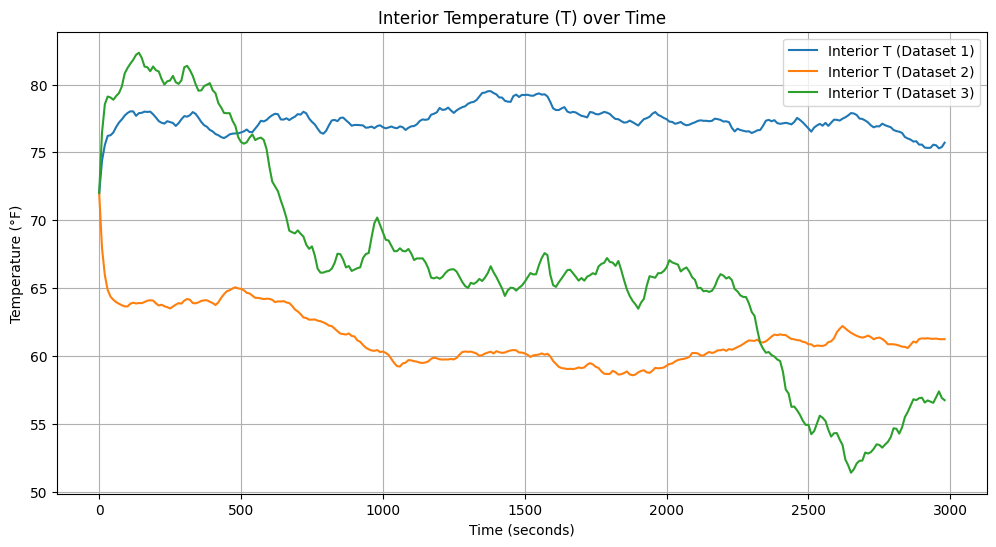

In [14]:
import numpy as np
import matplotlib.pyplot as plt


# Store them in a dictionary for easy access
all_datasets = {
    "Dataset 1": data_set_1,
    "Dataset 2": data_set_2,
    "Dataset 3": data_set_3
}

def solve_temperature(theta_data, h=10, k=0.05):
    """
    Solves T = A^-1 * b
    h: Time-step size
    k: Heat-transfer coefficient
    """
    n = len(theta_data)
    t = np.arange(0, n * h, h) # t_i increments by 10s starting from 0

    # Construct Matrix A
    A = np.eye(n)
    multiplier = -(1 - h * k)
    for i in range(1, n):
        A[i, i-1] = multiplier

    # Construct vector b
    # u_i
    b = np.zeros(n)
    b[0] = 72 # Initial condition T0 = 72

    for i in range(1, n):
        u_prev = 0.1 * k * np.sin((np.pi * (i-1) * h) / 10)
        b[i] = (h * k * theta_data[i-1]) + (h * u_prev)

    # Solve for T
    T = np.linalg.solve(A, b)
    return t, T

# 2. Loop through and plot
plt.figure(figsize=(12, 6))

for name, data in all_datasets.items():
    time, interior_temp = solve_temperature(data)

    plt.plot(time, interior_temp, label=f'Interior T ({name})')
    # Optional: plot the external theta for comparison
    # plt.plot(time, data, '--', alpha=0.3, label=f'External θ ({name})')

plt.title('Interior Temperature (T) over Time')
plt.xlabel('Time (seconds)') # Time on x-axis
plt.ylabel('Temperature (°F)') # Temperature on y-axis
plt.legend()
plt.grid(True)
plt.show()

### Plot 1 — Interior Temperature for All Three Datasets

Let's run the model and see what $T(t)$ looks like across all three datasets.
Each plot shows:
- **Teal/pink/orange line:** the interior temperature $T(t)$ we solved for.
- **Grey dashed line:** the outside temperature $\theta(t)$ from our spline,
  shown for comparison.
- **Pink dotted line:** the comfort level at $72^\circ$F.

The title of each subplot also reports the full temperature range and total swing,so we can immediately see how far from comfort the interior gets.

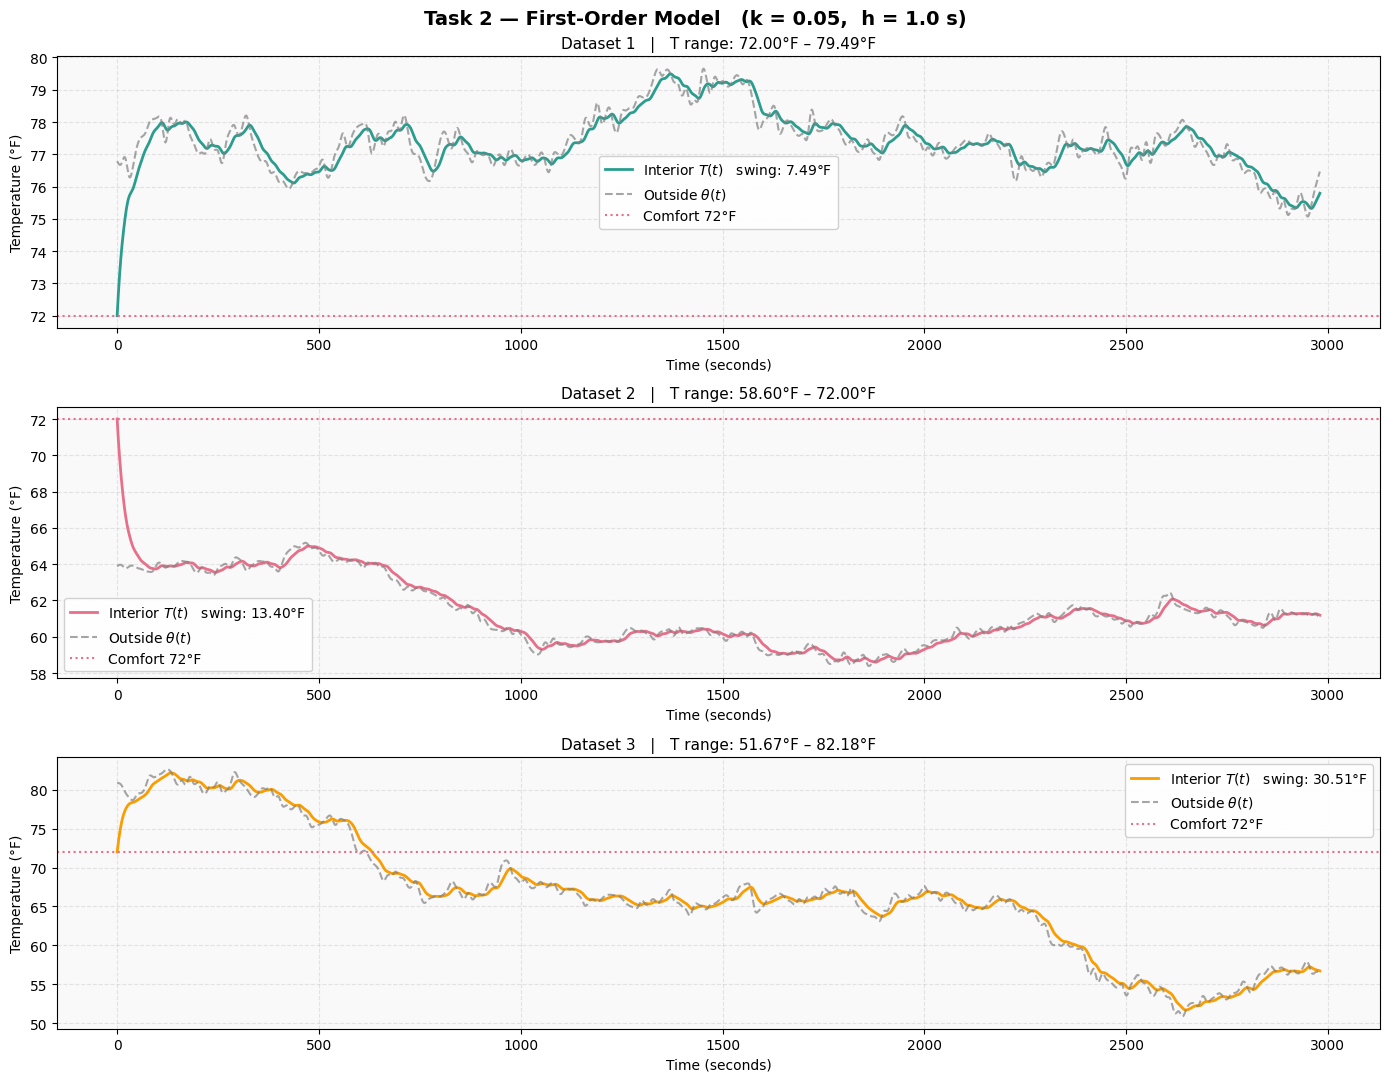

In [15]:
# -------------------------------------------------------
# Plot 1 — Interior temperature for all three datasets
# -------------------------------------------------------

k_val = 0.05
h_val = 1.0

fig, axes = plt.subplots(3, 1, figsize=(14, 11), facecolor='white')
fig.suptitle(f'Task 2 — First-Order Model   (k = {k_val},  h = {h_val} s)',
             fontsize=14, fontweight='bold')

colors_ds = ['#2A9D8F', '#E76F8A', '#FA9D00']

for idx, (theta_data, name, col) in enumerate(zip(datasets, dataset_names, colors_ds)):
    t_data = np.arange(len(theta_data)) * 10
    cs     = CubicSpline(t_data, theta_data, bc_type='natural')

    t_sol, T_sol = solve_first_order(theta_data, h=h_val, k=k_val)
    theta_fine   = cs(t_sol)

    ax = axes[idx]
    ax.set_facecolor('#F9F9F9')
    ax.plot(t_sol, T_sol,      color=col,    linewidth=2,
            label=f'Interior $T(t)$   swing: {T_sol.max()-T_sol.min():.2f}°F')
    ax.plot(t_sol, theta_fine, color='grey', linewidth=1.5,
            linestyle='--', alpha=0.7, label='Outside $\\theta(t)$')
    ax.axhline(72, color='#E76F8A', linestyle=':', linewidth=1.5,
               label='Comfort 72°F')
    ax.set_title(f'{name}   |   '
                 f'T range: {T_sol.min():.2f}°F – {T_sol.max():.2f}°F',
                 fontsize=11)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Temperature (°F)')
    ax.legend(framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('task2_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

### Plot 2 — What Happens When We Change $k$?

The parameter $k$ controls how strongly the interior reacts to the outside
temperature. Think of it as how "leaky" the carriage walls are.

- **Small $k$ (e.g. 0.001):** great insulation — the interior barely reacts to
  outside changes and stays very smooth.
- **Large $k$ (e.g. 0.1):** poor insulation — the interior chases the outside
  aggressively, picking up every small fluctuation in $\theta(t)$.

The plot below shows all four $k$ values for each dataset on the same axes.
Watch how the interior curve gets spikier and more reactive as $k$ increases.

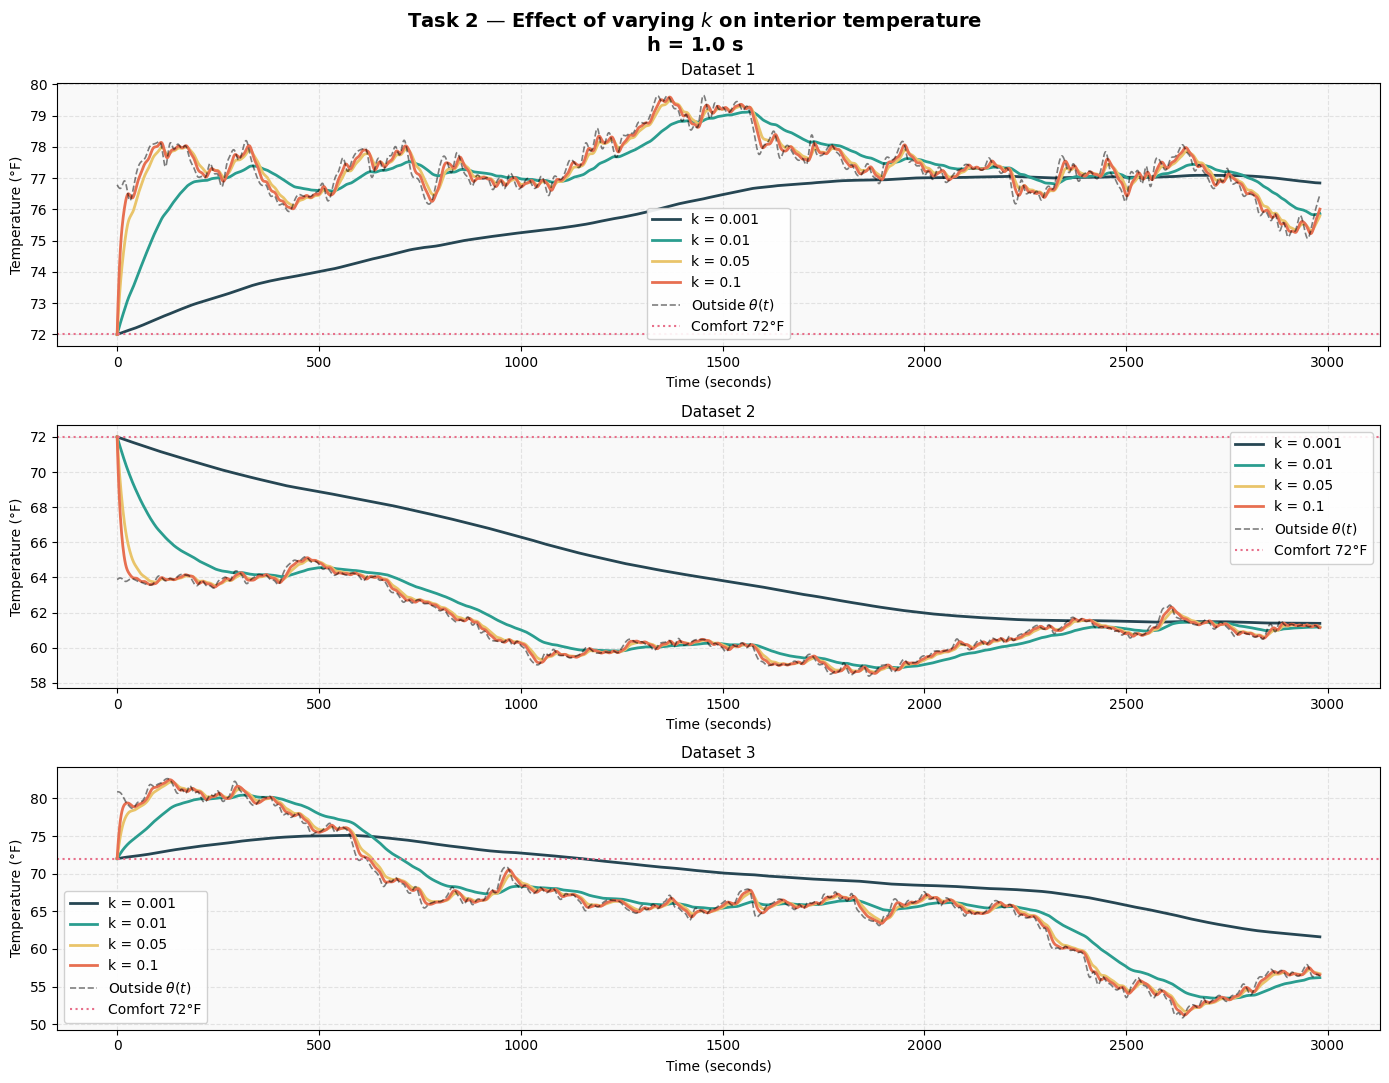

In [16]:
# -------------------------------------------------------
# Plot 2 — Effect of varying k (all three datasets)
# -------------------------------------------------------

k_values = [0.001, 0.01, 0.05, 0.1]
colors_k = ['#264653', '#2A9D8F', '#E9C46A', '#E76F51']

fig, axes = plt.subplots(3, 1, figsize=(14, 11), facecolor='white')
fig.suptitle('Task 2 — Effect of varying $k$ on interior temperature\n'
             f'h = {h_val} s',
             fontsize=14, fontweight='bold')

for idx, (theta_data, name) in enumerate(zip(datasets, dataset_names)):
    t_data = np.arange(len(theta_data)) * 10
    cs     = CubicSpline(t_data, theta_data, bc_type='natural')
    t_fine = np.linspace(0, 2980, 3000)

    ax = axes[idx]
    ax.set_facecolor('#F9F9F9')

    for k_v, col in zip(k_values, colors_k):
        t_sol, T_sol = solve_first_order(theta_data, h=h_val, k=k_v)
        ax.plot(t_sol, T_sol, color=col, linewidth=2, label=f'k = {k_v}')

    ax.plot(t_fine, cs(t_fine), color='black', linewidth=1.2,
            linestyle='--', alpha=0.5, label='Outside $\\theta(t)$')
    ax.axhline(72, color='#E76F8A', linestyle=':', linewidth=1.5,
               label='Comfort 72°F')
    ax.set_title(f'{name}', fontsize=11)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Temperature (°F)')
    ax.legend(framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('task2_vary_k.png', dpi=150, bbox_inches='tight')
plt.show()

### Plot 3 — Stability: What Happens When $h$ is Too Large?

The Forward Euler method comes with a condition for staying numerically stable:

$$h < \frac{2}{k}$$

If the step size $h$ exceeds this limit, the solution does not just become
slightly less accurate — it completely **blows up**, oscillating wildly and
growing without bound. This is a numerical artifact, not a physical result.

The plot below has two panels to show this clearly:

**Left panel — $h$ grows but never crosses the limit ($k = 0.01$, limit = $200$ s):**
We push $h$ all the way from $1$ second up to $150$ seconds. The solution gets
slightly less accurate as $h$ grows, but it never loses control because we are
always safely under the $200$ second stability limit. All four curves tell
essentially the same story.

**Right panel — $h$ crosses the limit and everything breaks ($k = 0.5$, limit = $4$ s):**
We use a larger $k = 0.5$ so the stability limit drops to just $4$ seconds,
making it easy to trigger the blowup. We compare $h = 3.5$ s (just under the
limit — stable) against $h = 5$ s (just over the limit — disaster). The
y-axis is clipped at $\pm 250°$F so the plot stays readable, but the
unstable solution would go to infinity if we let it run.

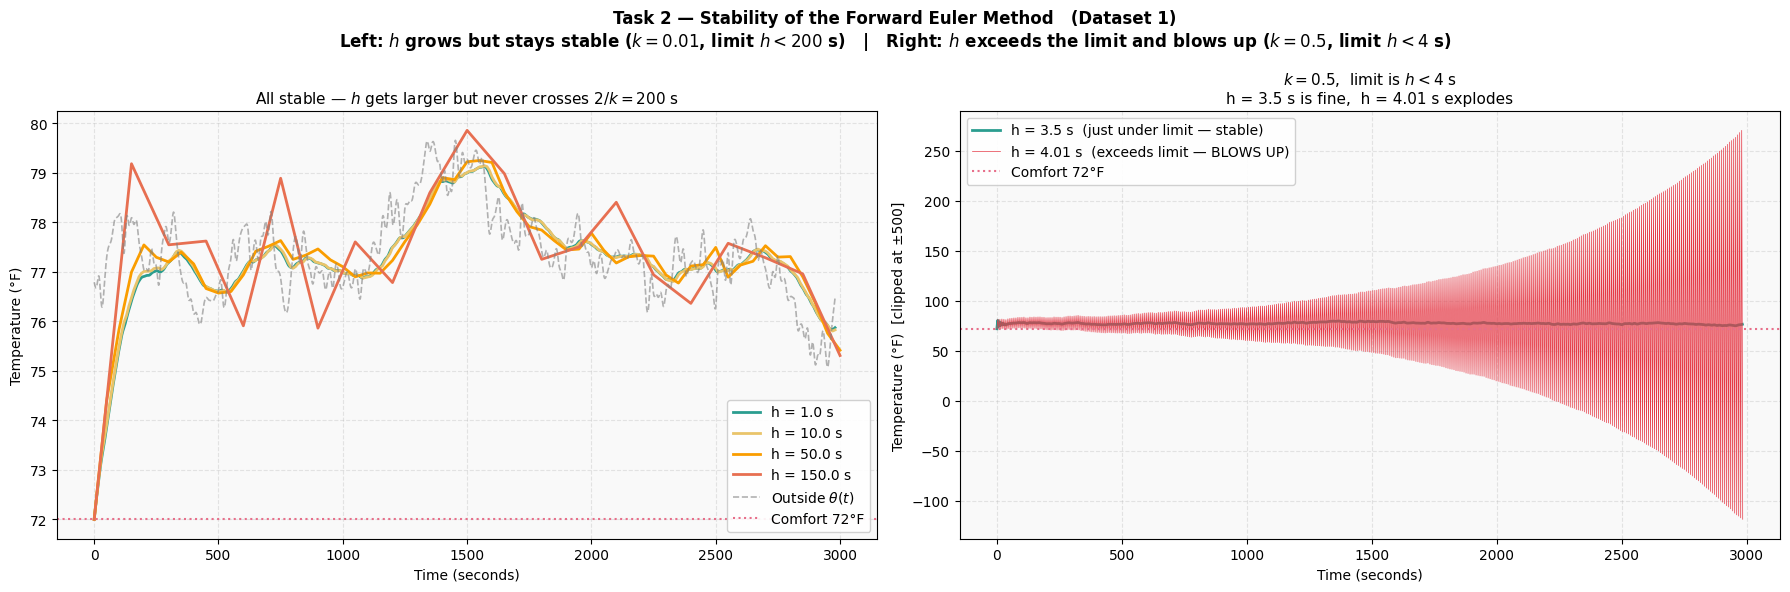

Left panel  — k = 0.01,  stability limit: h < 200 s
Right panel — k = 0.5,  stability limit: h < 4.0 s
h = 4.01 s exceeds the limit and blows up!


In [17]:
# -------------------------------------------------------
# Plot 3 — Stability: effect of step size h
# -------------------------------------------------------

# Left panel: h grows but stays stable (k=0.01, limit = 2/0.01 = 200s)
# We show h values that get progressively larger but all stay under 200s
k_stable  = 0.01
h_stable  = [1.0, 10.0, 50.0, 150.0]
colors_h  = ['#2A9D8F', '#E9C46A', '#FA9D00', '#E76F51']

# Right panel: one that actually blows up (k=0.5, limit = 2/0.5 = 4s)
# h=5 exceeds the limit so it blows up
k_blowup  = 0.5
h_blowup  = 4.01

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='white')
fig.suptitle('Task 2 — Stability of the Forward Euler Method   (Dataset 1)\n'
             'Left: $h$ grows but stays stable ($k=0.01$, limit $h < 200$ s)   |   '
             'Right: $h$ exceeds the limit and blows up ($k=0.5$, limit $h < 4$ s)',
             fontsize=12, fontweight='bold')

# ── Left panel: stable runs ────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#F9F9F9')

for h_v, col in zip(h_stable, colors_h):
    t_sol, T_sol = solve_first_order(data_set_1, h=h_v, k=k_stable)
    ax1.plot(t_sol, T_sol, color=col, linewidth=2,
             label=f'h = {h_v} s')

t_data = np.arange(len(data_set_1)) * 10
cs_1   = CubicSpline(t_data, data_set_1, bc_type='natural')
t_fine = np.linspace(0, 2980, 3000)
ax1.plot(t_fine, cs_1(t_fine), color='grey', linewidth=1.2,
         linestyle='--', alpha=0.6, label='Outside $\\theta(t)$')
ax1.axhline(72, color='#E76F8A', linestyle=':', linewidth=1.5,
            label='Comfort 72°F')
ax1.set_title(f'All stable — $h$ gets larger but never crosses $2/k = {2/k_stable:.0f}$ s',
              fontsize=11)
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Temperature (°F)')
ax1.legend(framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')

# ── Right panel: blowup ────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#F9F9F9')

# Show the stable solution just below the limit for comparison
h_just_under = 3.5
t_safe, T_safe = solve_first_order(data_set_1, h=h_just_under, k=k_blowup)
ax2.plot(t_safe, T_safe, color='#2A9D8F', linewidth=2,
         label=f'h = {h_just_under} s  (just under limit — stable)')

# Now the blowup
t_blow, T_blow = solve_first_order(data_set_1, h=h_blowup, k=k_blowup)
T_clipped      = np.clip(T_blow, -500, 500)   # clip so the plot stays readable
ax2.plot(t_blow, T_clipped, color='#E63946', linewidth=0.5,
         label=f'h = {h_blowup} s  (exceeds limit — BLOWS UP)',
        )

ax2.axhline(72, color='#E76F8A', linestyle=':', linewidth=1.5,
            label='Comfort 72°F')
ax2.set_title(f'$k = {k_blowup}$,  limit is $h < {2/k_blowup:.0f}$ s\n'
              f'h = {h_just_under} s is fine,  h = {h_blowup} s explodes',
              fontsize=11)
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Temperature (°F)  [clipped at ±500]')
ax2.legend(framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('task2_stability.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Left panel  — k = {k_stable},  stability limit: h < {2/k_stable:.0f} s')
print(f'Right panel — k = {k_blowup},  stability limit: h < {2/k_blowup:.1f} s')
print(f'h = {h_blowup} s exceeds the limit and blows up!')

### Task 2 Summary — What Did We Learn?

The first-order model gives us a reasonable picture of how the interior
temperature evolves, but there are a few key things to take away:

**1. Even a mild outside temperature causes discomfort.**
Dataset 1 shows that even when the outside is relatively stable, the interior
never just sits at 72°F. The climate-control oscillations and the pull from
a non-comfort outside temperature mean $E > 0$ for every journey.

**2. The insulation quality matters enormously.**
Varying $k$ shows that a well-insulated carriage ($k = 0.001$) barely feels
the outside at all, while a poorly insulated one ($k = 0.1$) tracks every
fluctuation in $\theta(t)$.

**3. Step size has real consequences.**
Choosing $h$ too large does not just reduce accuracy — it can make the
numerical solution completely meaningless. Always check $h < 2/k$.

**4. The model has one big physical limitation.**
It assumes the interior reacts *instantly* to outside changes. Real materials
have thermal inertia — they resist sudden temperature changes and respond with
a delay. That is what Task 3 addresses by adding a second derivative term.

Up next: Task 3

---
# Task 4: Thermal Exposure — How Uncomfortable Was the Ride?

Now that we have the interior temperature $T(t)$ from both models, we want to
summarize everything into **one number** that tells us how uncomfortable the
ride actually was. That number is called the **thermal exposure**:

$$E = \int_0^{t_{\max}} \bigl|T(t) - T_c\bigr|\,dt$$

where $T_c = 72^\circ$F is our comfort temperature.

The idea is simple:
- If the interior stays right at $72^\circ$F the whole time, $E = 0$ — perfect comfort.
- Every moment the temperature drifts away from $72^\circ$F, whether too hot
  or too cold, adds to $E$.
- Geometrically, $E$ is the **total shaded area between the temperature curve
  and the horizontal comfort line** at $72^\circ$F.
- The units are $^\circ$F$\cdot$s.

We compute $E$ three different ways to make sure our numerical integration is
reliable:

1. **Method 1 — Trapezoidal rule** applied directly to the discrete $T(t)$
   values. This is the baseline — no extra approximation involved.
2. **Method 2 — Polynomial interpolant** of $T(t)$ evaluated on a dense grid,
   then trapezoidal rule.
3. **Method 3 — Cubic spline** of $T(t)$ evaluated on a dense grid, then
   trapezoidal rule.

If all three methods give similar answers, we can trust that our result is
stable and not sensitive to which integration method we chose.

We do this for **both** interior temperature solutions — the Task 2 first-order
model and the Task 3 second-order model — so we can see how much the choice
of model affects the final discomfort estimate.

In [18]:
# -------------------------------------------------------
# Task 4 Setup — solvers and parameters
# -------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.integrate import trapezoid

datasets      = [data_set_1, data_set_2, data_set_3]
dataset_names = ['Dataset 1', 'Dataset 2', 'Dataset 3']

Tc      = 72.0
alpha   = 0.05
k       = 0.05
h       = 1.0
dt_data = 10.0

PINK = '#E76F8A'
TEAL = '#2A9D8F'
GREY = '#A0A0A0'

def u(t, k):
    return 0.1 * k * np.sin(np.pi * t / 10)

def solve_first_order(theta_data, h=1.0, k=0.01, T0=72.0, t_max=2980):
    t_data   = np.arange(len(theta_data)) * 10
    cs       = CubicSpline(t_data, theta_data, bc_type='natural')
    t_arr    = np.arange(0, t_max + h, h)
    T_arr    = np.zeros(len(t_arr))
    T_arr[0] = T0
    for i in range(len(t_arr) - 1):
        ti         = t_arr[i]
        theta_i    = float(cs(ti))
        u_i        = u(ti, k)
        T_arr[i+1] = (1 - h*k)*T_arr[i] + h*k*theta_i + h*u_i
    return t_arr, T_arr

def solve_task3(theta_data, h, alpha, k, T0=72.0, T_prime0=0.0, dt_data=10.0):
    N_data   = len(theta_data)
    t_data   = np.arange(N_data) * dt_data
    t_end    = t_data[-1]
    t_solver = np.arange(0, t_end + h, h)
    N        = len(t_solver)
    cs       = CubicSpline(t_data, theta_data)
    theta_s  = cs(t_solver)
    u_arr    = np.array([u(t_solver[i], k) for i in range(N)])
    cl = 1.0 - alpha * h / 2.0
    cd = -(2.0 - h**2 * k)
    cr = 1.0 + alpha * h / 2.0
    A  = np.zeros((N, N))
    b  = np.zeros(N)
    A[0, 0] = 1.0
    b[0]    = T0
    A[1, 1] = 2.0
    b[1]    = ((2.0 - h**2 * k) * T0
               + h**2 * k * theta_s[0]
               + h**2 * u_arr[0]
               + 2.0 * h * T_prime0 * cl)
    for i in range(2, N):
        A[i, i-2] = cl
        A[i, i-1] = cd
        A[i, i  ] = cr
        b[i]      = h**2 * k * theta_s[i-1] + h**2 * u_arr[i-1]
    T = np.linalg.solve(A, b)
    return t_solver, T, theta_s

print('Task 4 solvers and parameters ready!')

Task 4 solvers and parameters ready!


---
## Part 1: Thermal Exposure Using $T(t)$ from Task 2

Here we compute $E$ using the interior temperature from our **first-order
Forward Euler model**. Recall that this model assumes the interior reacts
instantly to outside changes, with no thermal inertia.

The three plots below show the shaded area between $T(t)$ and the $72^\circ$F
comfort line for each dataset. The total pink shaded area is $E$.

      PART 1 — THERMAL EXPOSURE FROM TASK 2 (FIRST-ORDER MODEL)       
Parameters: k = 0.05,  h = 1.0 s,  Tc = 72.0°F

Dataset 1:
  Method 1 — Trapezoidal (direct):      E = 15931.59 °F·s
  Method 3 — Cubic Spline:              E = 15931.60 °F·s
  Difference Methods 1 vs 3: 0.01 °F·s
  T range: 72.00°F – 79.49°F  |  Avg deviation: 5.346°F

Dataset 2:
  Method 1 — Trapezoidal (direct):      E = 31765.74 °F·s
  Method 3 — Cubic Spline:              E = 31765.76 °F·s
  Difference Methods 1 vs 3: 0.02 °F·s
  T range: 58.60°F – 72.00°F  |  Avg deviation: 10.660°F

Dataset 3:
  Method 1 — Trapezoidal (direct):      E = 24645.13 °F·s
  Method 3 — Cubic Spline:              E = 24645.15 °F·s
  Difference Methods 1 vs 3: 0.02 °F·s
  T range: 51.67°F – 82.18°F  |  Avg deviation: 8.270°F



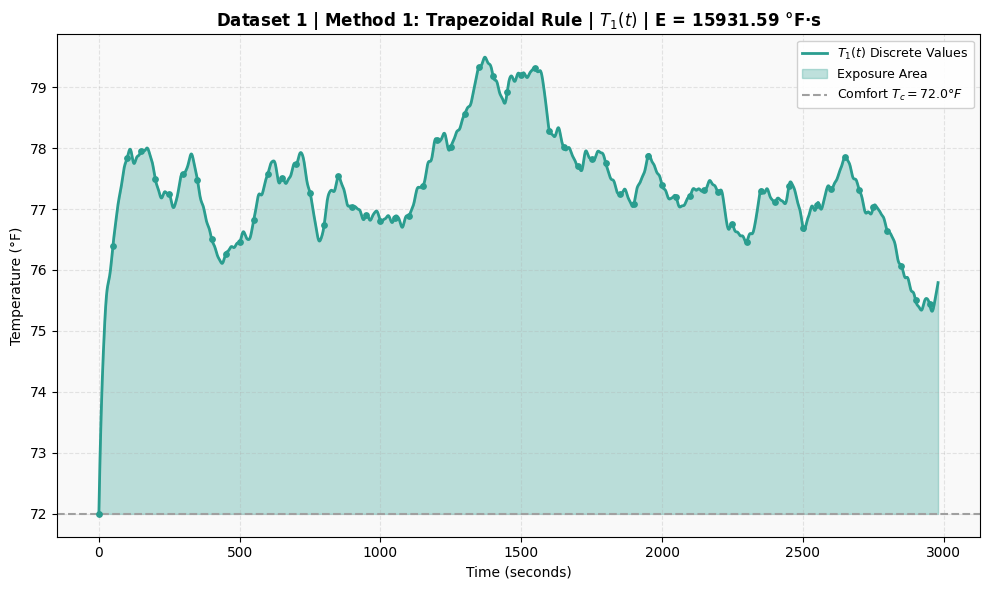

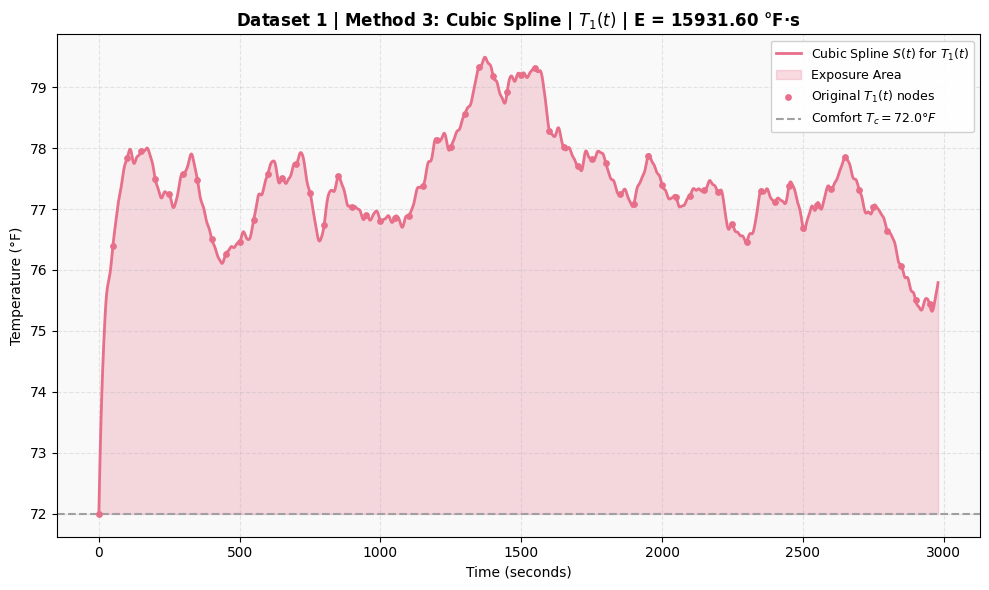

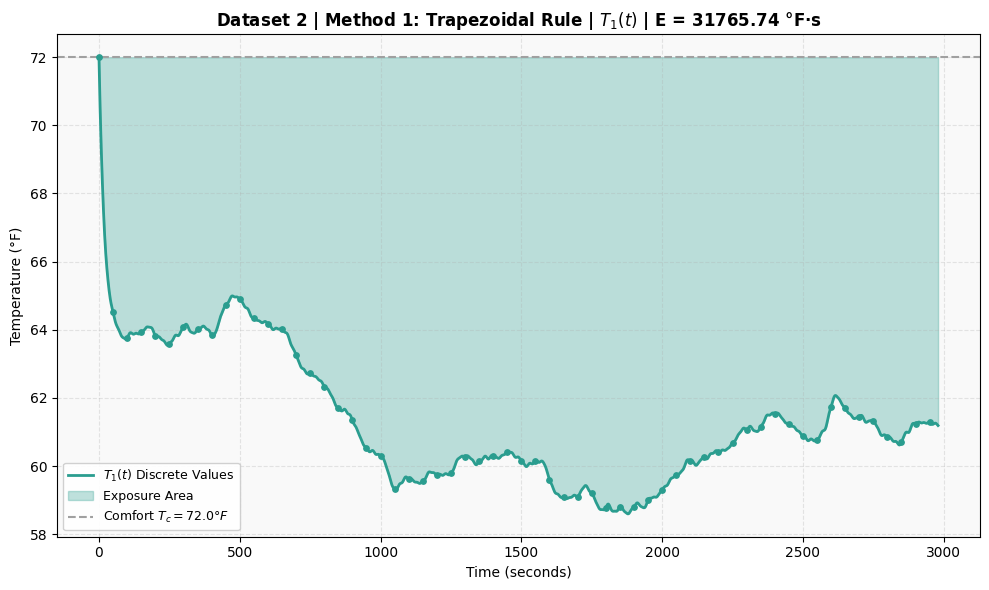

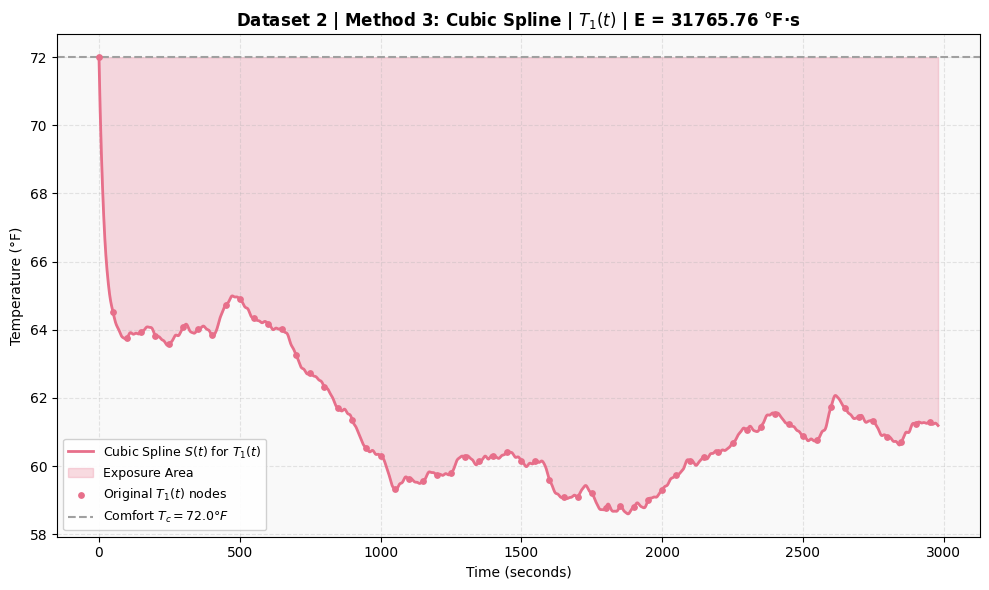

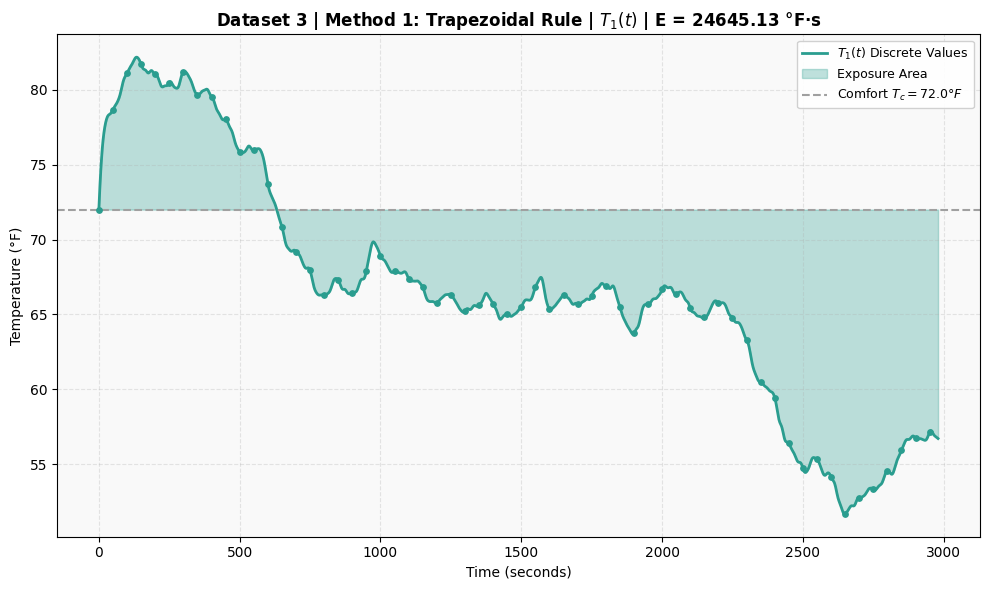

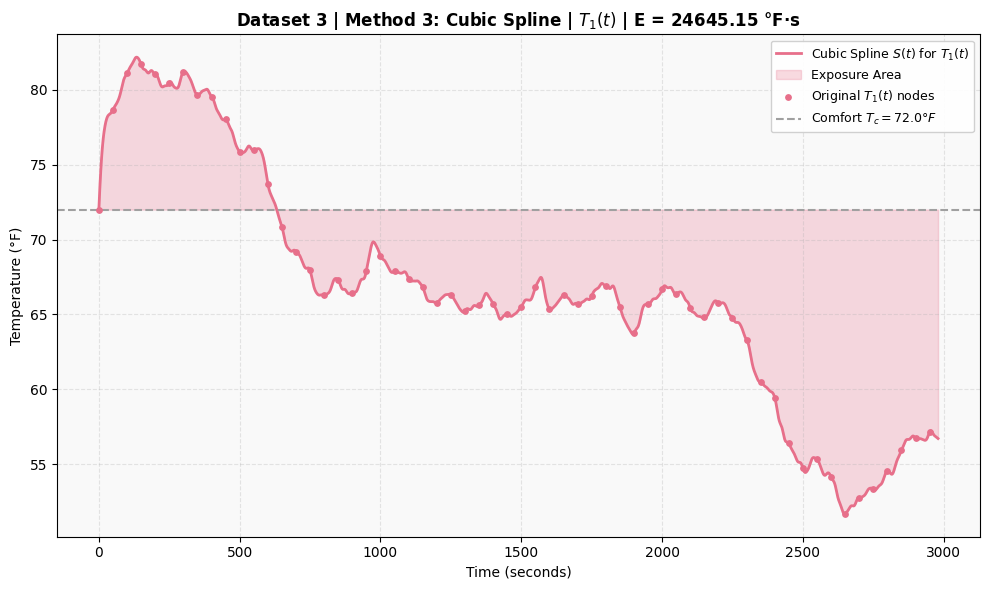

In [19]:
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import trapezoid

# -------------------------------------------------------
# Task 4 Part 1 — E from Task 2 (first-order model)
# -------------------------------------------------------

print('=' * 70)
print(f'{"PART 1 — THERMAL EXPOSURE FROM TASK 2 (FIRST-ORDER MODEL)":^70}')
print('=' * 70)
print(f'Parameters: k = {k},  h = {h} s,  Tc = {Tc}°F\n')

task2_results = []

for theta_data, name in zip(datasets, dataset_names):

    # Solve the first-order model for the current dataset
    t2, T2 = solve_first_order(theta_data, h=h, k=k)

    # Method 1: trapezoidal rule directly on the discrete T(t) values
    E1 = trapezoid(np.abs(T2 - Tc), t2)

    # Method 3: natural cubic spline interpolant on a fine grid
    t_fine  = np.linspace(t2[0], t2[-1], 5000)
    cs_T2   = CubicSpline(t2, T2, bc_type='natural')
    T_spline = cs_T2(t_fine)
    E3 = trapezoid(np.abs(T_spline - Tc), t_fine)

    task2_results.append({
        'name'    : name,
        'E_trap'  : E1,
        'E_spline': E3,
        't'       : t2,
        'T'       : T2,
        'T_spline': T_spline,
        't_fine'  : t_fine
    })

    print(f'{name}:')
    print(f'  Method 1 — Trapezoidal (direct):      E = {E1:.2f} °F·s')
    print(f'  Method 3 — Cubic Spline:              E = {E3:.2f} °F·s')
    print(f'  Difference Methods 1 vs 3: {abs(E1-E3):.2f} °F·s')
    print(f'  T range: {T2.min():.2f}°F – {T2.max():.2f}°F  |  '
          f'Avg deviation: {E1/t2[-1]:.3f}°F\n')

# -------------------------------------------------------
# Visualization — Separate Images for Every Graph
# -------------------------------------------------------

for res in task2_results:
    t_sol    = res['t']
    T_sol    = res['T']
    t_fine   = res['t_fine']
    T_spline = res['T_spline']
    name     = res['name']
    E1, E3   = res['E_trap'], res['E_spline']

    # --- GRAPH 1: METHOD 1 (Trapezoidal Rule) ---
    plt.figure(figsize=(10, 6), facecolor='white')
    ax1 = plt.gca()
    ax1.set_facecolor('#F9F9F9')
    ax1.plot(t_sol, T_sol, color=TEAL, linewidth=2, label='$T_1(t)$ Discrete Values')
    ax1.fill_between(t_sol, T_sol, Tc, alpha=0.30, color=TEAL, label='Exposure Area')
    ax1.scatter(t_sol[::50], T_sol[::50], color=TEAL, s=15, zorder=5)
    ax1.axhline(Tc, color=GREY, linestyle='--', linewidth=1.5, label=f'Comfort $T_c={Tc}°F$')

    # Heading with Dataset, Method, T1(t), and E value
    ax1.set_title(f'{name} | Method 1: Trapezoidal Rule | $T_1(t)$ | E = {E1:.2f} °F·s',
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Temperature (°F)')
    ax1.legend(framealpha=0.9, fontsize=9)
    ax1.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    # --- GRAPH 2: METHOD 3 (Cubic Spline Interpolation) ---
    plt.figure(figsize=(10, 6), facecolor='white')
    ax3 = plt.gca()
    ax3.set_facecolor('#F9F9F9')
    ax3.plot(t_fine, T_spline, color=PINK, linewidth=2, label='Cubic Spline $S(t)$ for $T_1(t)$')
    ax3.fill_between(t_fine, T_spline, Tc, alpha=0.25, color=PINK, label='Exposure Area')
    ax3.scatter(t_sol[::50], T_sol[::50], color=PINK, s=15, zorder=5, label='Original $T_1(t)$ nodes')
    ax3.axhline(Tc, color=GREY, linestyle='--', linewidth=1.5, label=f'Comfort $T_c={Tc}°F$')

    # Heading with Dataset, Method, T1(t), and E value
    ax3.set_title(f'{name} | Method 3: Cubic Spline | $T_1(t)$ | E = {E3:.2f} °F·s',
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('Time (seconds)')
    ax3.set_ylabel('Temperature (°F)')
    ax3.legend(framealpha=0.9, fontsize=9)
    ax3.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

---
## Task 4, Part 2: Thermal Exposure from Second-Order Model using Piecewise Lagrange Interpolation

This section uses the interior temperature `T(t)` obtained from our second-order ODE model (Task 3) and applies a custom piecewise Lagrange interpolation method to calculate the thermal exposure $E = \int_0^{t_{\max}} \bigl|T(t) - T_c\bigr|\,dt$. This method aims to provide a smooth, continuous representation of $T(t)$ without the instabilities seen with a single high-degree Lagrange polynomial.

      PART 2 — THERMAL EXPOSURE FROM TASK 2 (FIRST-ORDER MODEL)       
Parameters: k = 0.05, h = 1.0 s, Tc = 72.0°F


Dataset 1
  E (Piecewise Lagrange deg=3): 15931.57 °F·s


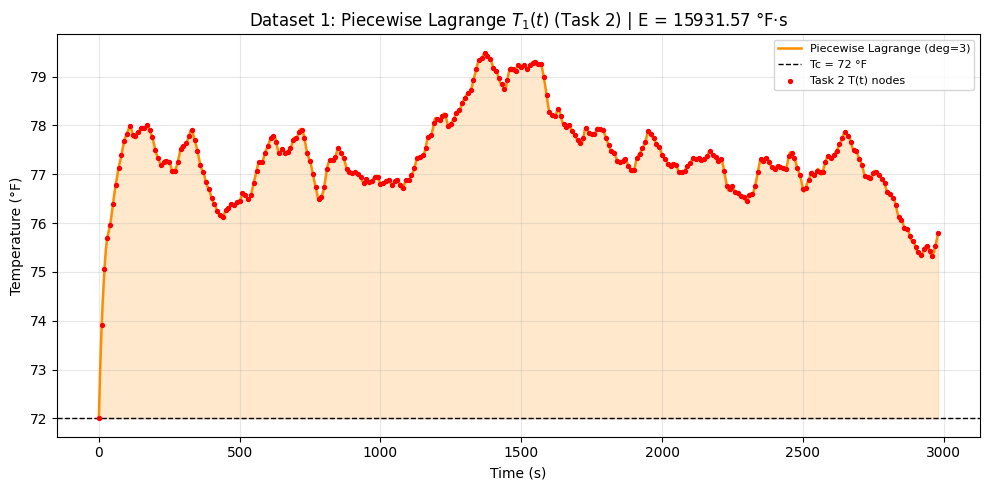


Dataset 2
  E (Piecewise Lagrange deg=3): 31765.70 °F·s


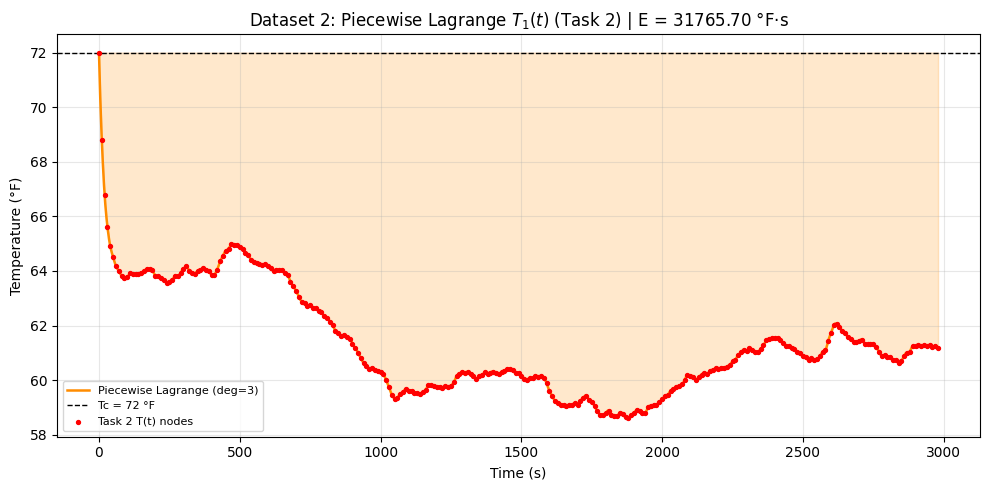


Dataset 3
  E (Piecewise Lagrange deg=3): 24645.09 °F·s


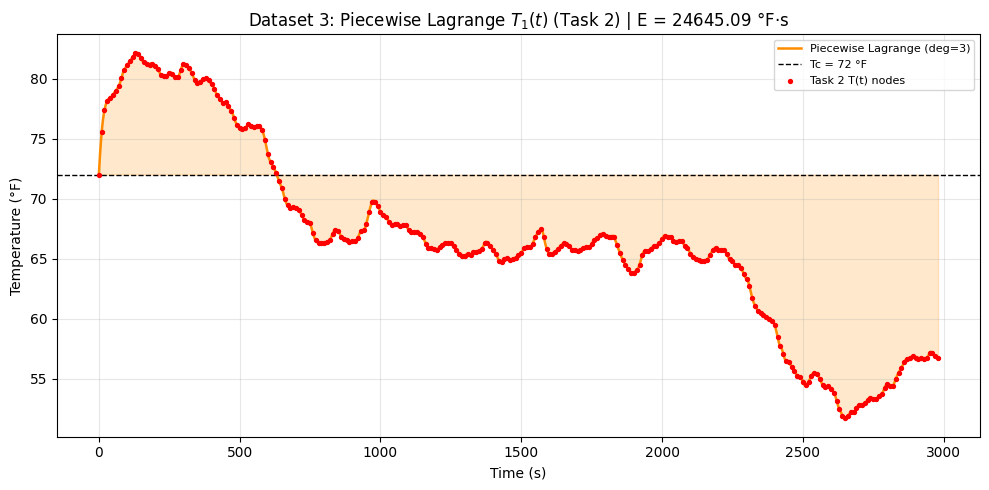

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline

# Assuming datasets, dataset_names, solve_first_order, solve_task3, alpha, k, dt_data
# are already defined from previous Task 2 and Task 3 executions.

Tc = 72.0
# alpha = 0.05  # alpha is not used in the first-order model
k = 0.05
h = 1.0
piecewise_degree = 3


def lagrange_basis(t_val, i, t_nodes):
    result = 1.0
    for j in range(len(t_nodes)):
        if j != i:
            result *= (t_val - t_nodes[j]) / (t_nodes[i] - t_nodes[j])
    return result


def lagrange_interpolate(t_val, t_nodes, theta_nodes):
    return sum(
        float(theta_nodes[i]) * lagrange_basis(t_val, i, t_nodes)
        for i in range(len(t_nodes))
    )


def integrate_exposure(t_fine, P_fine):
    """Trapezoid rule on |P(t) - Tc|."""
    trapz = getattr(np, 'trapezoid', np.trapz)
    return trapz(np.abs(P_fine - Tc), t_fine)


def piecewise_lagrange(t_fine, t_nodes, T_nodes, degree=3):
    """Evaluate a piecewise Lagrange interpolant on t_fine."""
    P_fine = np.zeros_like(t_fine)
    n = len(t_nodes)
    seg_size = degree + 1

    for start in range(0, n - 1, degree):
        end = min(start + seg_size, n)
        t_seg = t_nodes[start:end]
        T_seg = T_nodes[start:end]

        if len(t_seg) < 2:
            continue

        if start == 0:
            mask = (t_fine >= t_seg[0]) & (t_fine <= t_seg[-1])
        else:
            mask = (t_fine > t_seg[0]) & (t_fine <= t_seg[-1])

        for idx in np.where(mask)[0]:
            P_fine[idx] = lagrange_interpolate(t_fine[idx], t_seg, T_seg)

    return P_fine


print('=' * 70)
print(f'{"PART 2 — THERMAL EXPOSURE FROM TASK 2 (FIRST-ORDER MODEL)":^70}')
print('=' * 70)
print(f'Parameters: k = {k}, h = {h} s, Tc = {Tc}°F\n')

for theta_data, name in zip(datasets, dataset_names):
    print(f"\n{'=' * 55}")
    print(name)
    print(f"{'=' * 55}")

    # Use solve_first_order for Task 2 model output
    t_solver, T_solver = solve_first_order(theta_data, h=h, k=k)

    # Adjust step calculation since t_solver granularity is h, not dt_data
    # And t_nodes should align with T_solver to properly interpolate its output
    t_nodes = t_solver # Use all solver points as nodes for interpolation
    T_nodes = T_solver # Use all solver points as nodes for interpolation
    t_fine = np.linspace(t_nodes[0], t_nodes[-1], 2000)

    P_piecewise = piecewise_lagrange(
        t_fine,
        t_nodes,
        T_nodes,
        degree=piecewise_degree,
    )
    E_piecewise = integrate_exposure(t_fine, P_piecewise)

    print(f"  E (Piecewise Lagrange deg={piecewise_degree}): {E_piecewise:.2f} °F·s")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        t_fine,
        P_piecewise,
        color='darkorange',
        linewidth=1.8,
        label=f'Piecewise Lagrange (deg={piecewise_degree})',
    )
    ax.fill_between(t_fine, Tc, P_piecewise, alpha=0.2, color='darkorange')
    ax.axhline(Tc, color='black', linestyle='--', linewidth=1, label=f'Tc = {Tc:.0f} °F')
    ax.scatter(t_nodes[::int(dt_data/h)], T_nodes[::int(dt_data/h)], color='red', s=8, zorder=5, label='Task 2 T(t) nodes')

    # ADDED E VALUE TO HEADING
    ax.set_title(f'{name}: Piecewise Lagrange $T_1(t)$ (Task 2) | E = {E_piecewise:.2f} °F·s')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#Task 4 part 1 (copy)